# Worst Case Errors (WCEs) with Matern Kernels on Matrix Manifolds

In [1]:
import rmatqmcpy 
import torch
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
torch.set_default_dtype(torch.float64)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)

torch device = cpu
MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12


manifold_type = Stiefel
field = C
n = 4
nu = 5.5
log2_N_ref = 23
log2_N_max = 12
log2_N_rho = 11
trials = 1
pcg_log2_N_threshold = 14
pcg_residtol = 1.0e-04
k = 2
d = 12
r = 16
s = 11.5
s/d = 0.9583333333333334


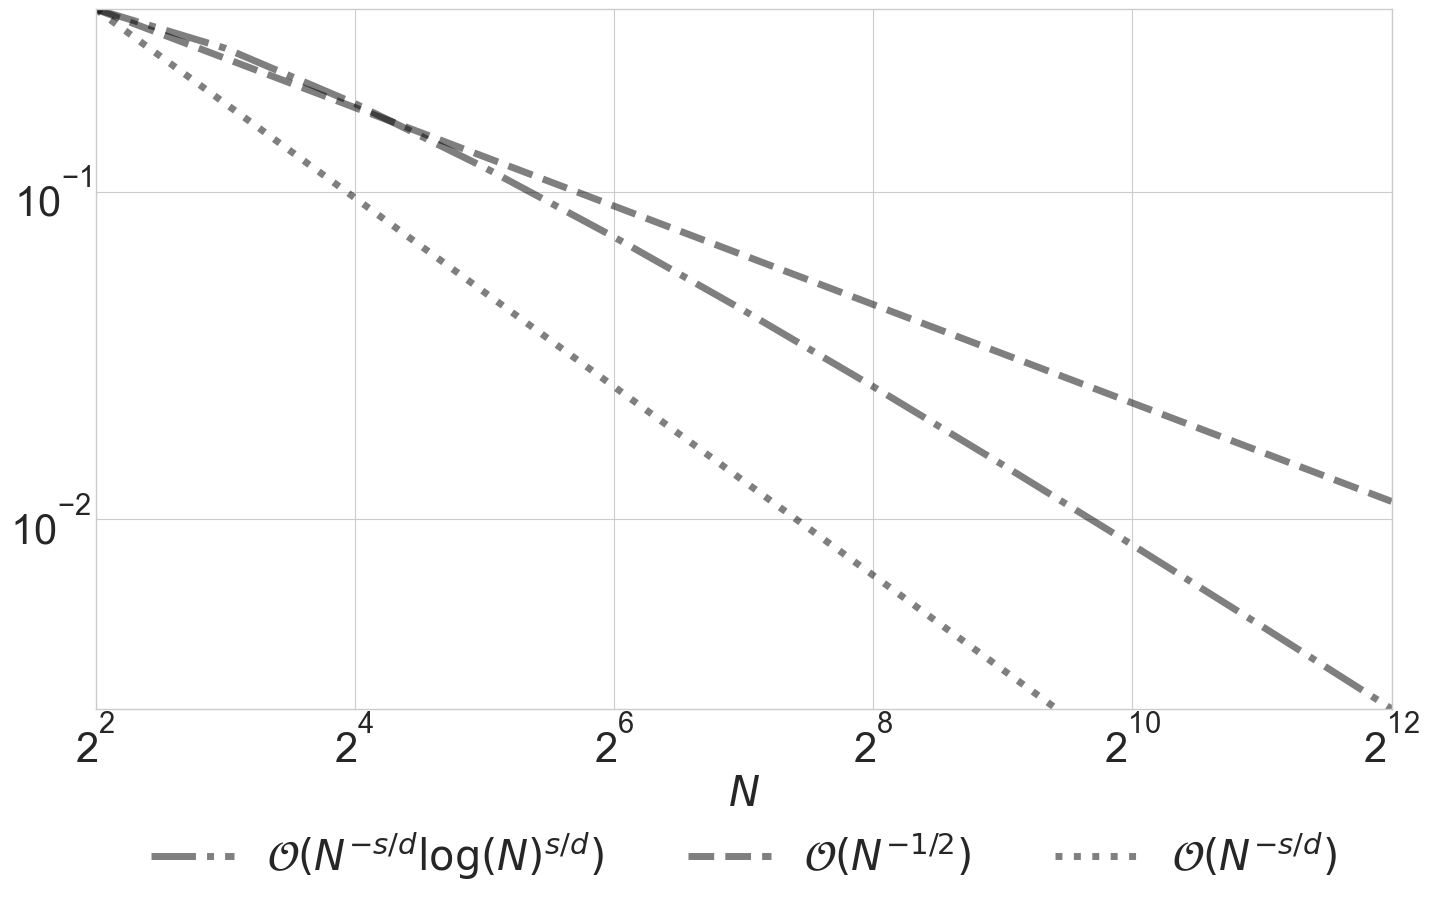

In [2]:
manifold_type = "Stiefel" # Stiefel, Gr, flag, LGr
field = "C" # R,C,H
n = 4 # 3,6
nu = 11/2 # 3/2,9/2
log2_N_ref = 23 # 26,24
log2_N_max = 12
log2_N_rho = 11
trials = 1
pcg_log2_N_threshold = 14
pcg_residtol = 1e-4
print("manifold_type = %s"%manifold_type)
print("field = %s"%field)
print("n = %d"%n)
print("nu = %.1f"%nu)
print("log2_N_ref = %d"%log2_N_ref)
print("log2_N_max = %d"%log2_N_max)
print("log2_N_rho = %d"%log2_N_rho)
print("trials = %d"%trials)
print("pcg_log2_N_threshold = %d"%pcg_log2_N_threshold)
print("pcg_residtol = %.1e"%pcg_residtol)
if manifold_type=="Stiefel":
    k = 2
    print("k = %d"%k)
    if field=="R":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_Stiefel_R(*args,k=k,**kwargs)
        d = int(n*k-k*(k+1)/2)
        r = int(n*k)
        decomp_kwarg = "rand_On"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_On_QR,"eig": rmatqmcpy.rand_On_eig}
    elif field=="C":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_Stiefel_C(*args,k=k,**kwargs)
        d = int(2*n*k-k**2)
        r = int(2*n*k)
        decomp_kwarg = "rand_Un"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_Un_QR,"eig": rmatqmcpy.rand_Un_eig}
    elif field=="H":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_Stiefel_H(*args,k=k,**kwargs)
        d = int(4*n*k-2*k**2+k)
        r = int(8*n*k)
        decomp_kwarg = "rand_Spn"
        decomp_map = {"default": None, "SVD": rmatqmcpy.rand_Spn_SVD}
    else: raise Exception("invalid field = %s"%field)
elif manifold_type=="Gr":
    k = 2
    print("k = %d"%k)
    if field=="R":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_Gr_R(*args,k=k,**kwargs)
        d = int(k*(n-k))
        r = int(n**2)
        decomp_kwarg = "rand_On"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_On_QR,"eig": rmatqmcpy.rand_On_eig}
    elif field=="C":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_Gr_C(*args,k=k,**kwargs)
        d = int(2*k*(n-k))
        r = int(2*n**2)
        decomp_kwarg = "rand_Un"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_Un_QR,"eig": rmatqmcpy.rand_Un_eig}
    elif field=="H":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_Gr_H(*args,k=k,**kwargs)
        d = int(4*k*(n-k))
        r = int(8*n**2)
        decomp_kwarg = "rand_Spn"
        decomp_map = {"default": None, "SVD": rmatqmcpy.rand_Spn_SVD}
    else: raise Exception("invalid field = %s"%field)
elif manifold_type=="flag":
    delta = torch.arange(1,n+1,dtype=torch.get_default_dtype(),device=DEVICE)
    delta = delta/torch.linalg.norm(delta)
    m = delta.unique(return_counts=True)[1]
    print("delta = %s"%str(delta))
    print("m = %s"%str(m))
    if field=="R":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_flag_R(*args,delta=delta,**kwargs)
        d = int(1/2*(n**2-(m**2).sum()))
        r = int(n**2)
        decomp_kwarg = "rand_On"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_On_QR,"eig": rmatqmcpy.rand_On_eig}
    elif field=="C":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_flag_C(*args,delta=delta,**kwargs)
        d = int((n**2-(m**2).sum()))
        r = int(2*n**2)
        decomp_kwarg = "rand_Un"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_Un_QR,"eig": rmatqmcpy.rand_Un_eig}
    elif field=="H":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_flag_H(*args,delta=delta,**kwargs)
        d = int(2*(n**2-(m**2).sum()))
        r = int(8*n**2)
        decomp_kwarg = "rand_Spn"
        decomp_map = {"default": None, "SVD": rmatqmcpy.rand_Spn_SVD}
    else: raise Exception("invalid field = %s"%field)
elif manifold_type=="LGr":
    if field=="R":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_LGr_R(*args,**kwargs)
        d = int(n*(n+1)/2)
        r = int(2*n**2)
        decomp_kwarg = "rand_Un"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_Un_QR,"eig": rmatqmcpy.rand_Un_eig}
    elif field=="C":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_LGr_C(*args,**kwargs)
        d = int(n*(n+1))
        r = int(8*n**2)
        decomp_kwarg = "rand_Spn"
        decomp_map = {"default": None, "SVD": rmatqmcpy.rand_Spn_SVD}
    elif field=="H":
        rand_manifold = lambda *args,**kwargs: rmatqmcpy.rand_LGr_H(*args,**kwargs)
        d = int(n*(2*n-1))
        r = int(8*n**2)
        decomp_kwarg = "rand_Un"
        decomp_map = {"default": None, "QR": rmatqmcpy.rand_Un_QR,"eig": rmatqmcpy.rand_Un_eig}
    else: raise Exception("invalid field = %s"%field)
else: raise Exception("invalid manifold_type = %s"%manifold_type)
s = nu+d/2
print("d = %d"%d)
print("r = %d"%r)
print("s = %s"%s)
print("s/d = %s"%(s/d))
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/2,MPLP["PW"]/2/1.5),sharex=True,sharey=False)
N_plot = 2**np.arange(2,13)
primary_trend = N_plot**(-s/d)*np.log(N_plot)**(s/d)
ax.plot(N_plot,primary_trend,color="k",alpha=0.5,linestyle="dashdot",label=r"$\mathcal{O}(N^{-s/d} \log(N)^{s/d})$")
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = [N_plot[0],N_plot[-1]]
# xmin,xmax = ax.get_xlim()
ymin,ymax = primary_trend.min(),primary_trend.max()
# ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-s/d})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.3))
ax.set_xlabel(r"$N$")
fig.tight_layout()
del N_plot,primary_trend

In [ ]:
x_ref = rand_manifold(N=2**0,n=n,seed=107,qp_unif_gen=lambda dimension,seed: qp.Net(dimension,seed=seed,randomize="DS",order="GRAY"))
y_ref = rand_manifold(N=2**log2_N_ref,n=n,seed=101,qp_unif_gen=lambda dimension,seed: qp.Net(dimension,seed=seed,randomize="DS",order="GRAY"))
N_rho = 2**log2_N_rho
fnorms = torch.linalg.norm(y_ref[:N_rho,None,:,:]-y_ref[None,:N_rho,:,:],dim=(-2,-1)).real
rho = fnorms[*torch.tril_indices(N_rho,N_rho,-1)].median().item()
print("rho = %.2e"%rho)
kernel = rmatqmcpy.KernelMatern(nu=nu,rho=rho)
kmean = kernel(x_ref[:,None,:,:],y_ref[None,:,:,:]).mean().item()
print("kmean = %.20f"%kmean)
del x_ref,y_ref,N_rho,fnorms

rho = 2.00e+00
kmean = 0.57229743205325589450


In [4]:
genf_ld_optw_decomp = [
    [r"IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",     False,      False,      "default"],
    [r"IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$",       False,      True,       "default"],
    # [r"QR LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",   True,       False,      "QR"], 
    # [r"Eig LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",  True,       False,      "eig"], 
    # [r"SVD LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$",  True,       False,      "SVD"], 
    ]
N = 2**torch.arange(2,log2_N_max+1)
seeds = [i for i in range(trials)]
wces = torch.nan*torch.empty((len(genf_ld_optw_decomp),len(N),trials))
t0 = time.perf_counter()
for i,(key,ld,optw,decomp) in enumerate(genf_ld_optw_decomp):
    print(key)
    if ld:
        qp_unif_gen = qp.IIDStdUniform
    else:
        qp_unif_gen=lambda dimension,seed: qp.Net(dimension,seed=seed,randomize="DS",order="GRAY")
    rand_decomp = decomp_map[decomp]
    kwargs_rand_manifold = {"qp_unif_gen":qp_unif_gen,decomp_kwarg:rand_decomp}
    for j in range(len(N)):
        print("    N = %d"%N[j])
        t0_ij = time.perf_counter()
        for t in range(trials):
            x = rand_manifold(N=N[j],n=n,device=DEVICE,seed=seeds[t],**kwargs_rand_manifold)
            if optw:
                w,wce2_p_kmean = rmatqmcpy.opt_weights_sum_1(x,kernel,use_pcg=2**pcg_log2_N_threshold,pcg_kwargs={"verbose":False,"residtol":pcg_residtol})
            else:
                w = torch.ones(N[j],device=DEVICE)/N[j]
                kmat = kernel(x[:,None,:,:],x[None,:,:,:])
                wce2_p_kmean = torch.einsum("...i,...ij,...j->...",w,kmat,w) # (...,)
            wces[i,j,t] = np.sqrt(max(0,float(wce2_p_kmean.cpu()-kmean)))
            print("        trial %-10d time %-10.1f wce %-10.1e"%(t,time.perf_counter()-t0,wces[i,j,t]))
        if (time.perf_counter()-t0_ij)/trials>2:
            break

IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$
    N = 4
        trial 0          time 0.0        wce 2.4e-01   
    N = 8
        trial 0          time 0.0        wce 1.4e-01   
    N = 16
        trial 0          time 0.0        wce 1.0e-01   
    N = 32
        trial 0          time 0.0        wce 6.6e-02   
    N = 64
        trial 0          time 0.0        wce 4.4e-02   
    N = 128
        trial 0          time 0.0        wce 2.8e-02   
    N = 256
        trial 0          time 0.0        wce 2.0e-02   
    N = 512
        trial 0          time 0.0        wce 1.1e-02   
    N = 1024
        trial 0          time 0.1        wce 8.6e-03   
    N = 2048
        trial 0          time 0.5        wce 6.2e-03   
    N = 4096
        trial 0          time 2.0        wce 4.9e-03   
IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
    N = 4
        trial 0          time 2.0        wce 2.4e-01   
    N = 8
        trial 0          time 2.0        wce 1.4e-01   
    N = 16
        trial 0          time

In [5]:
def genflag_opt_x_w(
        N,
        delta,
        seed=None,
        verbose = False, 
        iters = 100,
        eps_kmat = 1e-8,
        verbose_indent = 4,
        ):
    assert manifold_type=="flag"
    assert field=="R"
    t = delta.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(N)).to(DEVICE)
    theta0 = rmatqmcpy.tf_On_QR(u)
    zerosn = torch.zeros(N,device=DEVICE)
    onesn = torch.ones(N,device=DEVICE)
    eyen = torch.eye(N,device=DEVICE)
    def wce_recip_loss(theta):
        q = agsutil.to_unitary_qr(theta)
        x = torch.einsum("...ij,...j,...kj->...ik",q,delta,q)
        kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (N,N)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (N,N)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        return v,x,L
    u,x,L = agsutil.lm_opt(
        f = wce_recip_loss,
        theta0 = theta0,
        ytrue = zerosn,
        iters = iters,
        lam0 = 1e0,
        verbose = verbose,
        verbose_indent = verbose_indent,
        loss_mult = -1,
        # store_data_iters = True,
    )
    # print(data["losses_quantiles"]["50"])
    # print(data["losses_quantiles"]["50"][1:]-data["losses_quantiles"]["50"][:-1])
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    w = w/w.sum(-1,keepdim=True)
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (N,N)
    wce2_p_kmean = torch.einsum("...i,...ij,...j->...",w,kmat,w) # (...,)
    return x,w,wce2_p_kmean
# genflag_opt_x_w(
#     N = 2**4, 
#     delta=delta,
#     seed = 17,
#     verbose = None)
if False and manifold_type=="flag" and field=="R":
    genf_ld_optw_decomp += [[r"Opt $\mathcal{X}$ ~ Opt $\boldsymbol{w}$", "opt", "opt", "default"]]
    wces_opt_x_w = torch.nan*torch.empty((len(N),trials))
    t0 = time.perf_counter()
    for j in range(len(N)):
        print("    N = %d"%N[j])
        t0_ij = time.perf_counter()
        for t in range(trials):
            x,w,wce2_p_kmean = genflag_opt_x_w(N=N[j],delta=delta,seed=seeds[t],verbose=False)
            wces_opt_x_w[j,t] = np.sqrt(max(0,float(wce2_p_kmean.cpu()-kmean)))
            print("        trial %-10d time %-10.1f wce %-10.1e"%(t,time.perf_counter()-t0,wces[i,j,t]))
        if (time.perf_counter()-t0_ij)/trials>2:
            break
    wces = torch.cat([wces,wces_opt_x_w[None,:,:]],dim=0)

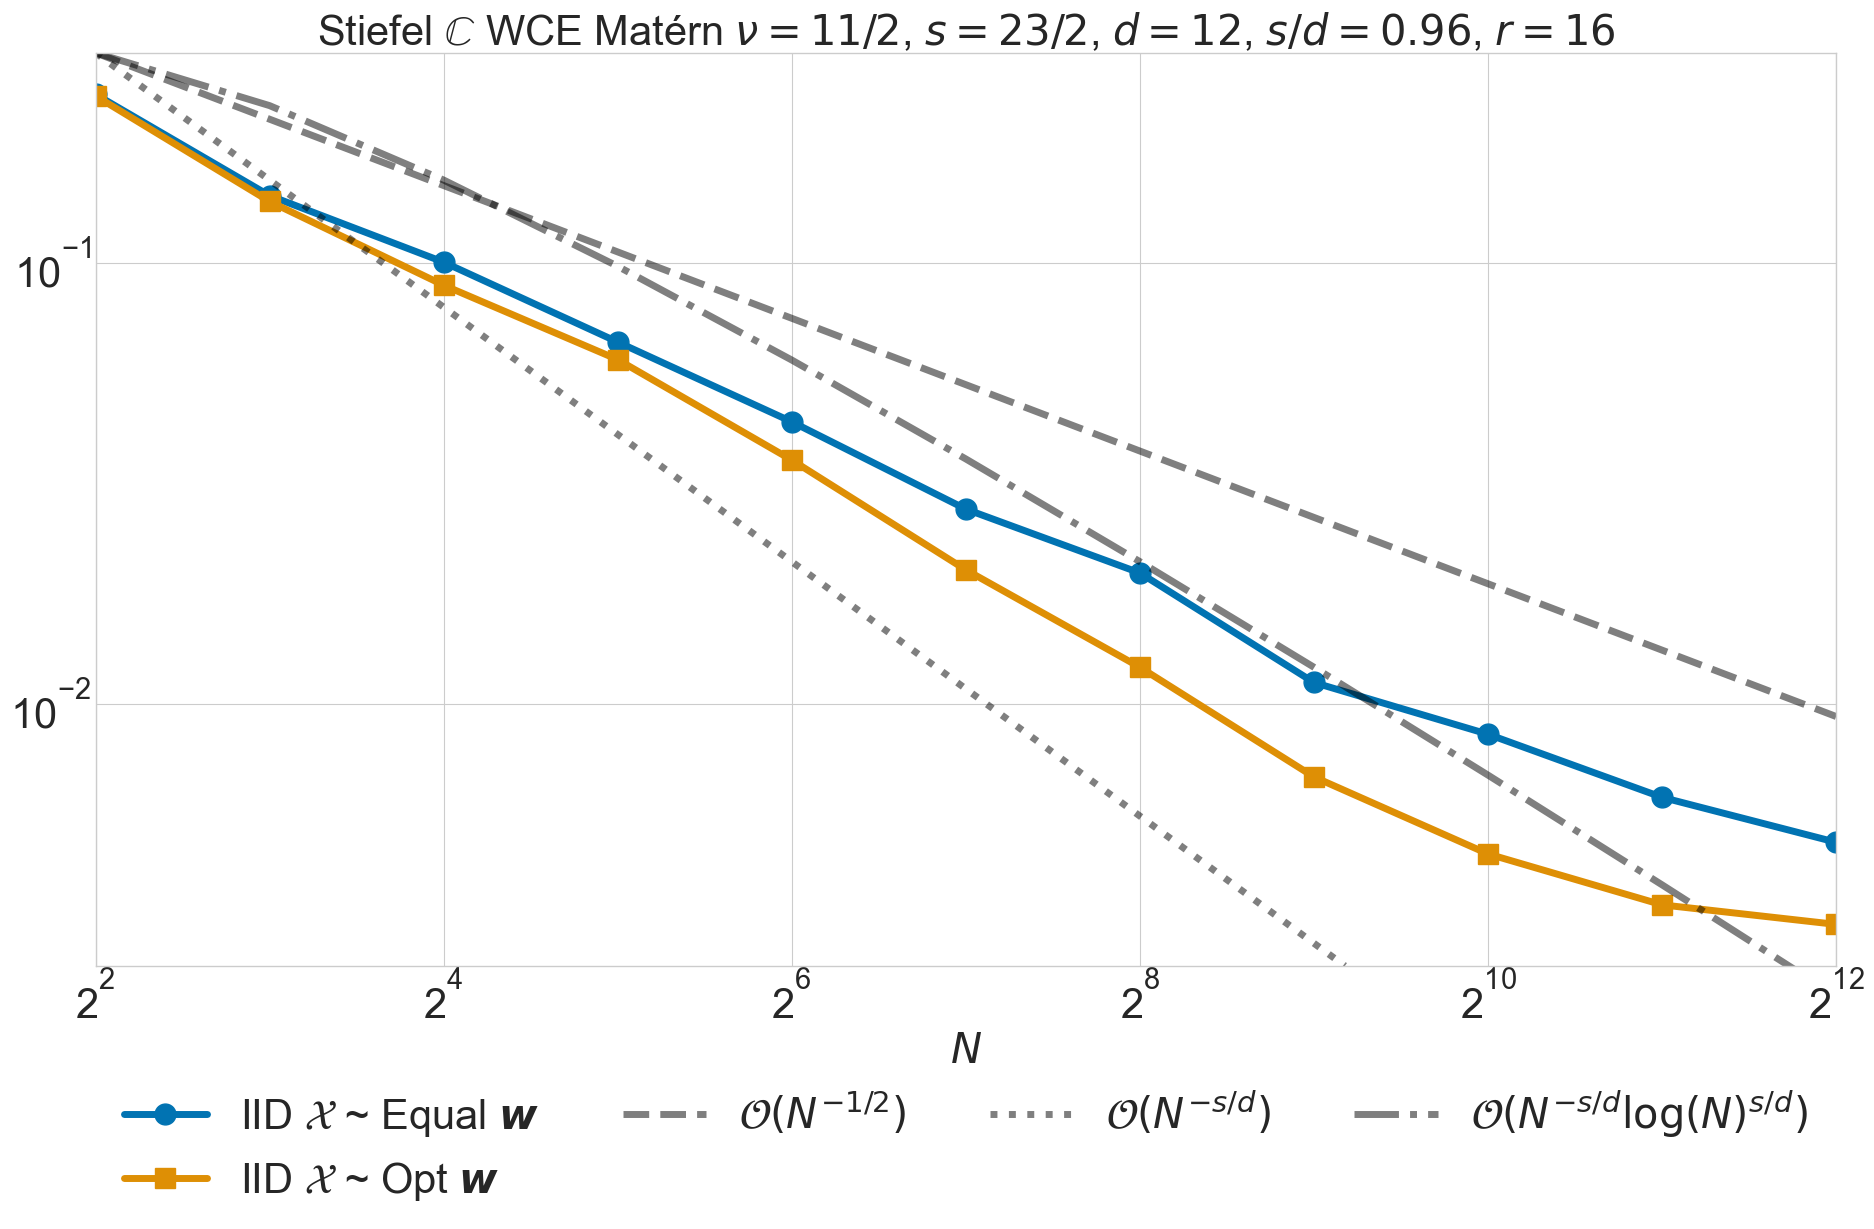

In [6]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/1.5/1.5),sharex=True,sharey=False)
wces_means = wces.mean(-1)
for i,(key,*_) in enumerate(genf_ld_optw_decomp):
    ax.plot(N,wces_means[i],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = [N[0],N[-1]]
# xmin,xmax = ax.get_xlim()
ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
# ax.axline([xmax,ymin],[2*xmax,2**(-1/2)*ymin],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-1/2})$",linestyle="dashed")
# ax.axline([xmax,ymin],[2*xmax,2**(-s/d)*ymin],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-s/d})$",linestyle="dotted")
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(N^{-s/d})$",linestyle="dotted")
ax.plot(N,ymax/(xmin**(-s/d)*np.log(xmin)**(s/d))*N**(-s/d)*np.log(N)**(s/d),color="k",alpha=0.5,linestyle="dashdot",label=r"$\mathcal{O}(N^{-s/d} \log(N)^{s/d})$")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.3))
assert s==np.inf or s%1 in [0,1/2]
if s==np.inf:
    s_str = r"\infty"
elif s%1==0:
    s_str = r"%d"%s 
elif s%1==1/2:
    s_str = r"%d/2"%(2*s)
ax.set_title(manifold_type+r" $\mathbb{%s}$"%field+r" WCE Matérn "+kernel.nu_str+r", $s = %s$"%s_str+r", $d=%d$"%d+r", $s/d = %.2f$"%(s/d)+r", $r=%d$"%r)
ax.set_xlabel(r"$N$")
fig.tight_layout()
fig.savefig("./out/WCE.%s_%s.n%d.d%d.nu%s.png"%(manifold_type,field,n,d,nu))

In [7]:
wces_df = pd.DataFrame(wces.mean(-1).T,columns=[name for (name,*_) in genf_ld_optw_decomp])
wces_df['N'] = N
wces_df = wces_df.set_index('N')
print(r"WCEs")
wces_df

WCEs


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$
N,,
4,0.241688,0.239720
8,0.142404,0.138133
16,0.100613,0.089197
32,0.066296,0.060486
64,0.043713,0.035799
128,0.027707,0.020176
256,0.019853,0.012134
512,0.011205,0.006844
1024,0.008552,0.004577
